### Lu_Fe distance analysis

In [1]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib.patches import Patch as LegendPatch
import numpy as np

sys.path.append("..")
import roi_tools

experimental_source = hs.load("../data/images/HAADF/HAADF_Buena.dm3")
experimental_signal = experimental_source.isig[20:2028, 200:1948]
grid_creator = roi_tools.GridCreator()
experimental_layout = grid_creator.detect_layout(experimental_signal)
experimental_grid = grid_creator.process(
    experimental_signal, layout=experimental_layout
)
experimental_fe_mask = experimental_grid.atom_type_mask("Fe")

lufe_indices = np.load("LuFe_indicies.npy")
detected_lufe_mask = np.zeros(experimental_grid.shape, dtype=bool)
detected_lufe_mask[tuple(lufe_indices.T)] = True

In [2]:
(
    lu_singlet_distance_map,
    lu_doublet_distance_map,
    lu_class_map,
) = roi_tools.PositionAnalyzer().get_Lu_phases(experimental_grid)

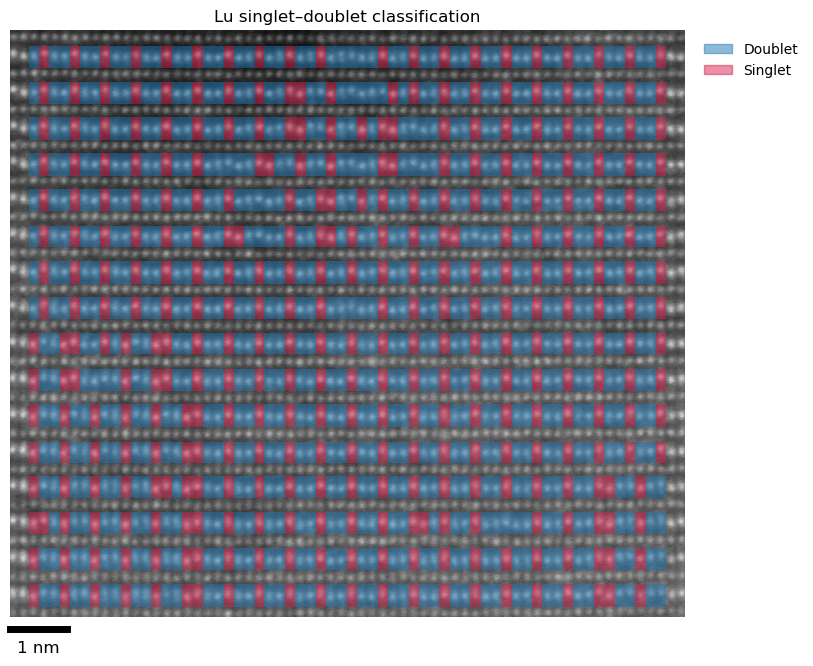

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Lu singlet–doublet classification'}>)

In [3]:
classification_colors = {"Doublet": "#1f77b4", "Singlet": "#D6204E"}
fig, ax = plt.subplots(figsize=(10, 10))
classification_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
for class_value, label in ((-1, "Doublet"), (1, "Singlet")):
    classification_plotter.add_boolean_faces(
        lu_class_map == class_value,
        color=classification_colors[label],
        alpha=0.5,
    )

ax.legend(
    handles=[
        LegendPatch(color=color, alpha=0.5, label=label)
        for label, color in classification_colors.items()
    ],
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
)
ax.set_title("Lu singlet–doublet classification")
fig.subplots_adjust(right=0.8)
classification_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

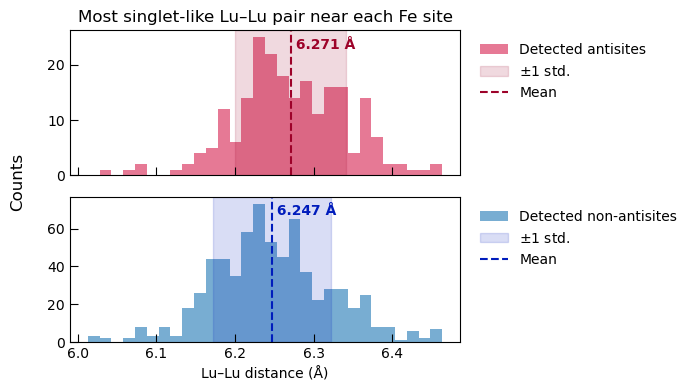

In [4]:
experimental_positions = roi_tools.PositionAnalyzer().fit(experimental_grid)
scale_angstrom = experimental_signal.axes_manager.signal_axes[0].scale * 10
distance_groups = {
    "Detected antisites": [],
    "Detected non-antisites": [],
}
offsets = np.array([-1, 0, 1])
n_columns, n_rows = experimental_grid.shape

for i in range(2, n_columns - 2):
    for j in range(1, n_rows - 1):
        if not experimental_fe_mask[i, j]:
            continue

        lu_rows = [j - 1, j + 1]
        pair_singlet_distances = np.array([
            lu_singlet_distance_map[i + offset, lu_rows].mean()
            for offset in offsets
        ])
        best_offset = offsets[np.argmin(pair_singlet_distances)]
        z = experimental_positions[i + best_offset, lu_rows, 1]
        distance = abs(z[1] - z[0]) * scale_angstrom

        group = (
            "Detected antisites"
            if detected_lufe_mask[i, j]
            else "Detected non-antisites"
        )
        distance_groups[group].append(distance)

defect_distances = np.asarray(distance_groups["Detected antisites"])
pristine_distances = np.asarray(distance_groups["Detected non-antisites"])
distance_bins = np.histogram_bin_edges(
    np.concatenate((defect_distances, pristine_distances)), bins=30
)

fig, axes = plt.subplots(
    2, 1, figsize=(6, 4), sharex=True,
    gridspec_kw={"height_ratios": [1, 1]},
)

for ax, values, color, stat_color, label in zip(
    axes,
    (defect_distances, pristine_distances),
    ("#D6204E", "#1f77b4"),
    ("#9D0229", "#001cbc"),
    distance_groups,
):
    mean = values.mean()
    std = values.std()
    ax.hist(values, bins=distance_bins, color=color, alpha=0.6, label=label)
    ax.axvspan(
        mean - std, mean + std, color=stat_color, alpha=0.15,
        label=r"$\pm 1$ std.",
    )
    ax.axvline(mean, color=stat_color, linestyle="--", label="Mean")
    ax.text(
        mean, 0.95, f" {mean:.3f} Å",
        transform=ax.get_xaxis_transform(), va="top",
        color=stat_color, fontweight="bold",
    )
    ax.tick_params(direction="in", length=6)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

axes[0].set_title("Most singlet-like Lu–Lu pair near each Fe site")
axes[1].set_xlabel("Lu–Lu distance (Å)")
fig.supylabel("Counts", x=0)
fig.subplots_adjust(hspace=0.15, right=0.75, left=0.1, bottom=0.1)
plt.show()

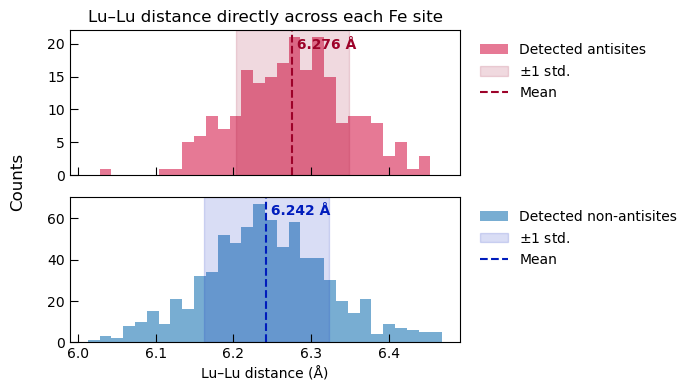

In [5]:
direct_distance_groups = {label: [] for label in distance_groups}

for i in range(n_columns):
    for j in range(1, n_rows - 1):
        if not experimental_fe_mask[i, j]:
            continue

        z = experimental_positions[i, [j - 1, j + 1], 1]
        distance = abs(z[1] - z[0]) * scale_angstrom
        group = (
            "Detected antisites"
            if detected_lufe_mask[i, j]
            else "Detected non-antisites"
        )
        direct_distance_groups[group].append(distance)

direct_defect_distances = np.asarray(
    direct_distance_groups["Detected antisites"]
)
direct_pristine_distances = np.asarray(
    direct_distance_groups["Detected non-antisites"]
)
direct_bins = np.histogram_bin_edges(
    np.concatenate((direct_defect_distances, direct_pristine_distances)),
    bins=30,
)

fig, axes = plt.subplots(
    2, 1, figsize=(6, 4), sharex=True,
    gridspec_kw={"height_ratios": [1, 1]},
)
for ax, values, color, stat_color, label in zip(
    axes,
    (direct_defect_distances, direct_pristine_distances),
    ("#D6204E", "#1f77b4"),
    ("#9D0229", "#001cbc"),
    direct_distance_groups,
):
    mean = values.mean()
    std = values.std()
    ax.hist(
        values, bins=direct_bins, color=color, alpha=0.6, label=label
    )
    ax.axvspan(
        mean - std, mean + std, color=stat_color, alpha=0.15,
        label=r"$\pm 1$ std.",
    )
    ax.axvline(
        mean, color=stat_color, linestyle="--", label="Mean"
    )
    ax.text(
        mean, 0.95, f" {mean:.3f} Å",
        transform=ax.get_xaxis_transform(), va="top",
        color=stat_color, fontweight="bold",
    )
    ax.tick_params(direction="in", length=6)
    ax.legend(
        frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
    )

axes[0].set_title("Lu–Lu distance directly across each Fe site")
axes[1].set_xlabel("Lu–Lu distance (Å)")
fig.supylabel("Counts", x=0)
fig.subplots_adjust(hspace=0.15, right=0.75, left=0.1, bottom=0.1)
plt.show()

In [6]:
from pathlib import Path

from tqdm.auto import tqdm

simulation_rng = np.random.default_rng(0)
n_fp = 50
simulation_layers = np.arange(25)
simulation_scale_angstrom = 0.05


def indexed_simulation_files(folder, pattern):
    return sorted(
        folder.glob(pattern),
        key=lambda path: int(path.stem.rsplit("_", 1)[1]),
    )


def mean_ensemble(files, indices):
    return np.mean(
        np.stack([np.load(files[index]).squeeze() for index in indices]),
        axis=0,
    )


def random_index_sets(n_available, n_images):
    return [
        simulation_rng.choice(n_available, n_fp, replace=False)
        for _ in range(n_images)
    ]


middle_layer_distances = []
all_layer_distances = []
# defect_image_counts = {"LuFe_singlet": 10, "LuFe_doublet": 20}
defect_image_counts = {"LuFe_doublet": 30}

for defect, n_images in defect_image_counts.items():
    defect_directory = Path("../data/simulations") / defect
    files_by_layer = {
        layer: indexed_simulation_files(
            defect_directory / f"{defect}_layer_{layer}",
            f"{defect}_layer_{layer}_ensemble_*.npy",
        )
        for layer in simulation_layers
    }
    index_sets = random_index_sets(len(files_by_layer[0]), n_images)
    layout_image = mean_ensemble(files_by_layer[0], index_sets[0])
    layout = grid_creator.detect_layout(hs.signals.Signal2D(layout_image))

    for layer in tqdm(simulation_layers, desc=f"Fitting {defect}"):
        for indices in index_sets:
            image = mean_ensemble(files_by_layer[layer], indices)
            grid = grid_creator.process(
                hs.signals.Signal2D(image), layout=layout
            )
            positions = roi_tools.PositionAnalyzer().fit(grid)
            z = positions[3, [2, 4], 1]
            distance = abs(z[1] - z[0]) * simulation_scale_angstrom
            all_layer_distances.append(distance)
            if 2 <= layer <= 10:
                middle_layer_distances.append(distance)

middle_layer_distances = np.asarray(middle_layer_distances)
all_layer_distances = np.asarray(all_layer_distances)

Fitting LuFe_doublet:   0%|          | 0/25 [00:00<?, ?it/s]

In [7]:
pristine_scale_angstrom = 0.05

pristine_files = indexed_simulation_files(
    Path("../data/simulations/pristine_fp"), "pristine_fp_*.npy"
)
pristine_index_sets = random_index_sets(len(pristine_files), 30)
pristine_layout_image = mean_ensemble(
    pristine_files, pristine_index_sets[0]
)
pristine_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(pristine_layout_image)
)
simulated_pristine_distances = []

for indices in tqdm(pristine_index_sets, desc="Fitting pristine"):
    image = mean_ensemble(pristine_files, indices)
    grid = grid_creator.process(
        hs.signals.Signal2D(image), layout=pristine_layout
    )
    positions = roi_tools.PositionAnalyzer().fit(grid)
    fe_mask = grid.atom_type_mask("Fe")
    lu_mask = grid.atom_type_mask("Lu")
    for i in range(grid.shape[0]):
        for j in range(1, grid.shape[1] - 1):
            if not (
                fe_mask[i, j]
                and lu_mask[i, j - 1]
                and lu_mask[i, j + 1]
            ):
                continue
            z = positions[i, [j - 1, j + 1], 1]
            if np.all(np.isfinite(z)):
                simulated_pristine_distances.append(
                    abs(z[1] - z[0]) * pristine_scale_angstrom
                )

simulated_pristine_distances = np.asarray(
    simulated_pristine_distances
)

Fitting pristine:   0%|          | 0/30 [00:00<?, ?it/s]

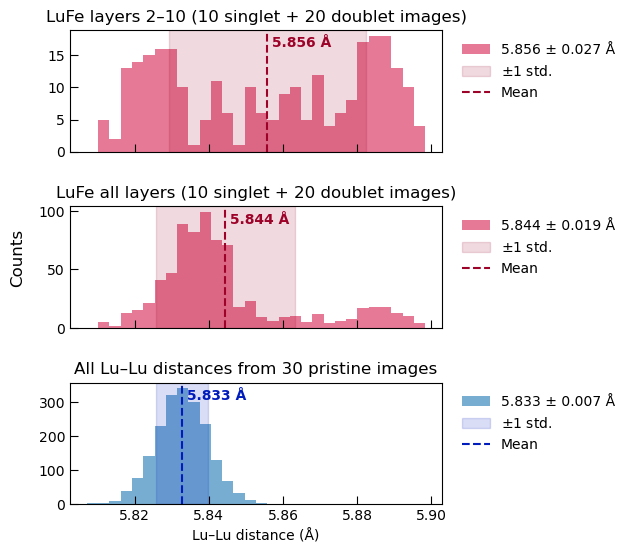

In [8]:
simulation_distance_bins = np.histogram_bin_edges(
    np.concatenate((
        middle_layer_distances,
        all_layer_distances,
        simulated_pristine_distances,
    )),
    bins=30,
)

plot_groups = (
    (
        middle_layer_distances, "#D6204E", "#9D0229",
        "LuFe layers 2–10 (10 singlet + 20 doublet images)",
    ),
    (
        all_layer_distances, "#D6204E", "#9D0229",
        "LuFe all layers (10 singlet + 20 doublet images)",
    ),
    (
        simulated_pristine_distances, "#1f77b4", "#001cbc",
        "All Lu–Lu distances from 30 pristine images",
    ),
)

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
for ax, (values, color, stat_color, title) in zip(axes, plot_groups):
    mean = values.mean()
    std = values.std()
    ax.hist(
        values, bins=simulation_distance_bins, color=color, alpha=0.6,
        label=f"{mean:.3f} ± {std:.3f} Å",
    )
    ax.axvspan(
        mean - std, mean + std, color=stat_color, alpha=0.15,
        label=r"$\pm 1$ std.",
    )
    ax.axvline(mean, color=stat_color, linestyle="--", label="Mean")
    ax.text(
        mean, 0.95, f" {mean:.3f} Å",
        transform=ax.get_xaxis_transform(), va="top",
        color=stat_color, fontweight="bold",
    )
    ax.set_title(title)
    ax.tick_params(direction="in", length=6)
    ax.legend(
        frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
    )

axes[-1].set_xlabel("Lu–Lu distance (Å)")
fig.supylabel("Counts", x=0)
fig.subplots_adjust(hspace=0.45, right=0.72, left=0.1, bottom=0.09)
plt.show()